# Demo: Drone Proximity to Threat Evaluation

This notebook showcases the ability of the drone to detect and respond to threats in the Contingency scenario.

```
Copyright © 2024, United States Government, as represented by the Administrator of the National Aeronautics and Space Administration. All rights reserved.

The “"Fault Model Design tools - fmdtools version 2"” software is licensed under the Apache License, Version 2.0 (the "License"); you may not use this file except in compliance with the License. You may obtain a copy of the License at http://www.apache.org/licenses/LICENSE-2.0. 

Unless required by applicable law or agreed to in writing, software distributed under the License is distributed on an "AS IS" BASIS, WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied. See the License for the specific language governing permissions and limitations under the License.
```

In [1]:
from fmdtools_examples.airspacelib.contingency_management.model_aircraft import ContingencyAircraftArchitecture, plot_flightpath, properties, collections
from fmdtools.define.architecture.function import FunctionArchitectureGraph

from fmdtools.sim import propagate as prop

The model builds on the Contingency model showcased in `demo_notebook.ipynb`.

In [2]:
haa = ContingencyAircraftArchitecture()

This work added a `GeomArchitecture` to represent the spacial boundaries of the drone and other aircraft which may be in the airspace.

As shown below, the scenario considered has one drone (called `self`) and another drone (called `uav`) that fly over the environment. `self` has a defined flightpath from its start to end location (from the lower left to upper right), and `uav` is considered a rogue uav that has a flight that interferes with the flightplan (flying from the lower right to the upper left).

The `Geom` objects for each define:
- The `envelope`, which is the physical boundary of the object
- The `speed` boundary, which defines the boundary of where the object could be at the next timestep
- The `safety` boundary, which is minimum safe distance the objects must be from each other

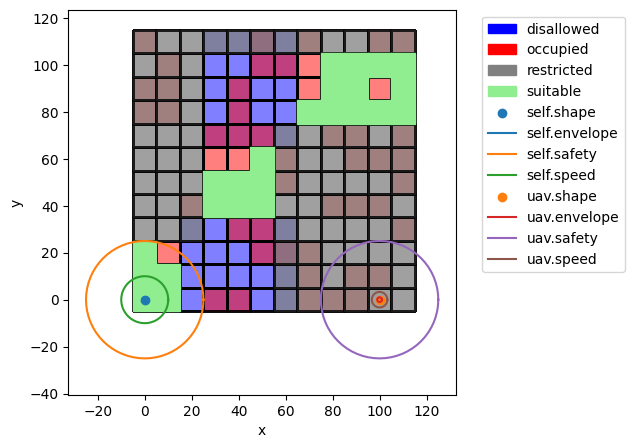

In [3]:
fig, ax = haa.flows['environment'].c.show(properties=properties, collections=collections)
fig, ax = haa.flows['environment'].ga.show(fig=fig, ax=ax)

To avoid hitting the UAV, a behavior was added to the aircraft that causes it to pause its flight if it within the safety boundary of the external UAV.

This is a very simple avoidance maneuver and would not help in a wide range of scenarios (e.g., if the UAV was flying towards it rather than in front of it). Nevertheless, it can demonstrate the value of ProxThreat functionality when simulated:

In [4]:
res, hist = prop.nominal(haa)

As shown here, the behavior activates a few times during the flight, causing it to enter the `pause` mode when the `closest_dist` (the distance to the safety envelope of the `uav`) is 0:

(<Figure size 600x400 with 4 Axes>,
 array([<Axes: title={'center': 'flows.electricity.s.charge'}, xlabel=' '>,
        <Axes: title={'center': 'fxns.control_flight.m.mode'}, xlabel=' '>,
        <Axes: title={'center': 'fxns.control_flight.s.closest_dist'}, xlabel='time'>,
        <Axes: title={'center': 'fxns.aviate.m.mode'}, xlabel='time'>],
       dtype=object))

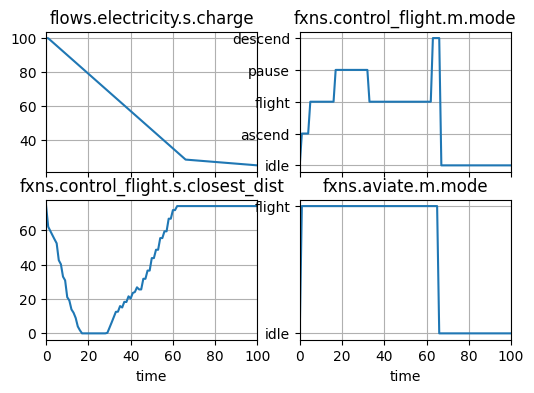

In [5]:
hist.plot_line('flows.electricity.s.charge',
               'fxns.control_flight.m.mode',
               'fxns.control_flight.s.closest_dist',
               'fxns.aviate.m.mode')

We can see this behavior illustrated below, which shows the specific times in which `self` has paused so as to not encroach on the `uav`.

As shown, `self` goes right inside the safety envelope, where it stops.

In [6]:
geoms = {'self': {'shapes': {'envelope': {'color': 'blue'}}},
         'uav': {'shapes': {'safety': {'color': 'orange'}}}}

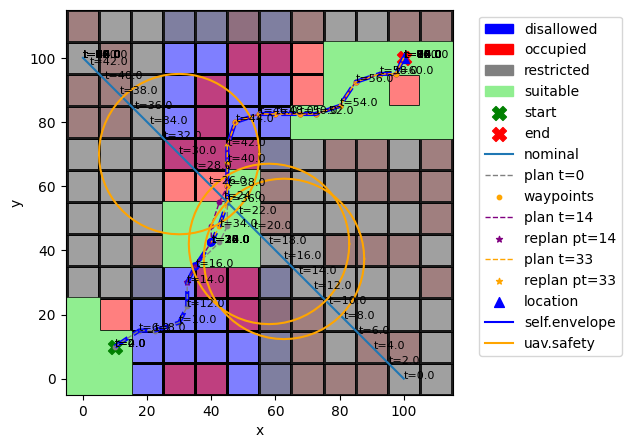

In [7]:
fig, ax = plot_flightpath(haa, hist, time_ticks=2.0, time_groups='nominal')
fig, ax = hist.plot_trajectories('environment.ga.geoms.uav.s.x',
                                 'environment.ga.geoms.uav.s.y',
                                 fig=fig, ax=ax, time_groups='nominal', time_ticks=2.0)
fig, ax = haa.flows['environment'].ga.show_from(hist.flows.environment.ga, 16, fig=fig, ax=ax, geoms=geoms)
fig, ax = haa.flows['environment'].ga.show_from(hist.flows.environment.ga, 18, fig=fig, ax=ax, geoms=geoms)
fig, ax = haa.flows['environment'].ga.show_from(hist.flows.environment.ga, 30, fig=fig, ax=ax, geoms=geoms)

We can see the alternative behavior without proxthreat below:

In [8]:
haa2 = ContingencyAircraftArchitecture(p={'with_proxthreat': False})
res, hist = prop.nominal(haa2)

C:\Users\dhulse\Documents\GitHub\fmdtools\src\fmdtools\sim\propagate.py:691: UserWarning: Faults found during the nominal run {'control_flight.loss': Fault(prob=1.0, cost=0.0, phases=(), disturbances=(), units=sim), 'aviate.crash': Fault(prob=1.0, cost=0.0, phases=(), disturbances=(), units=sim), 'store_and_supply_ee.break': Fault(prob=1.0, cost=0.0, phases=(), disturbances=(), units=sim), 'perceive_environment.break': Fault(prob=1.0, cost=0.0, phases=(), disturbances=(), units=sim), 'hold_payload.break': Fault(prob=1.0, cost=0.0, phases=(), disturbances=(), units=sim)}
  warnings.warn("Faults found during the nominal run " + str(endfaults))


(<Figure size 600x400 with 4 Axes>,
 array([<Axes: title={'center': 'flows.electricity.s.charge'}, xlabel=' '>,
        <Axes: title={'center': 'fxns.control_flight.m.mode'}, xlabel=' '>,
        <Axes: title={'center': 'fxns.control_flight.s.closest_dist'}, xlabel='time'>,
        <Axes: title={'center': 'fxns.aviate.m.mode'}, xlabel='time'>],
       dtype=object))

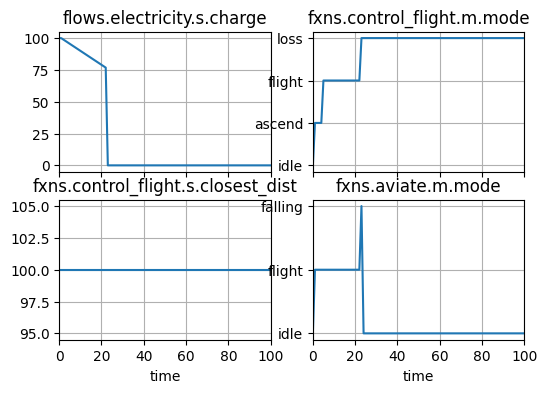

In [9]:
hist.plot_line('flows.electricity.s.charge',
               'fxns.control_flight.m.mode',
               'fxns.control_flight.s.closest_dist',
               'fxns.aviate.m.mode')

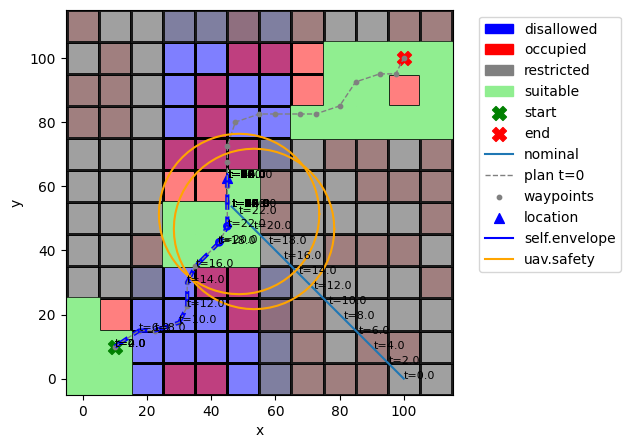

In [10]:
fig, ax = plot_flightpath(haa2, hist, time_groups='nominal', time_ticks=2.0)
fig, ax = hist.plot_trajectories('environment.ga.geoms.uav.s.x',
                                 'environment.ga.geoms.uav.s.y',
                                 fig=fig, ax=ax, time_groups='nominal', time_ticks=2.0)
fig, ax = haa2.flows['environment'].ga.show_from(hist.flows.environment.ga, 20, fig=fig, ax=ax, geoms=geoms)
fig, ax = haa2.flows['environment'].ga.show_from(hist.flows.environment.ga, 22, fig=fig, ax=ax, geoms=geoms)
# fig, ax = haa2.flows['environment'].ga.show_from(hist.flows.environment.ga, 16, fig=fig, ax=ax, geoms=geoms)
# fig, ax = haa2.flows['environment'].ga.show_from(hist.flows.environment.ga, 18, fig=fig, ax=ax, geoms=geoms)

As shown, both aircraft get very close to each other at time `t=22.0`, resulting in a likely crash